In [6]:
%reset
import numpy as np
import torch
import torch.nn as nn
import scipy.io

from scipy.stats import qmc
import matplotlib.pyplot as plt

Nothing done.


In [7]:
# -----------------------
# Reproducibility + dtype
# -----------------------
np.random.seed(0)
torch.manual_seed(0)

DTYPE = torch.float64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# -----------------------
# Load data (cylinder_nektar_wake.mat)
# -----------------------
data = scipy.io.loadmat("../data/cylinder_nektar_wake.mat")

X_star = data["X_star"]          # (N, 2)
x = X_star[:, 0:1]               # (N, 1)
y = X_star[:, 1:2]               # (N, 1)

t = data["t"]                    # (nt, 1)

U_star = data["U_star"]          # (N, 2, nt)
u = U_star[:, 0, :]              # (N, nt)
v = U_star[:, 1, :]              # (N, nt)

p = data["p_star"]               # (N, nt) (optional, not used below)

print("x:", x.shape, "y:", y.shape, "t:", t.shape)
print("u:", u.shape, "v:", v.shape, "p:", p.shape)



x: (5000, 1) y: (5000, 1) t: (200, 1)
u: (5000, 200) v: (5000, 200) p: (5000, 200)


In [9]:
# -----------------------
# Build snapshots matrix X for POD
# -----------------------
X = u


In [10]:
# -----------------------
# Train/test split
# -----------------------
nt = X.shape[1]
train_frac = 0.7
k_split = int(train_frac * nt)

train_idx = np.arange(0, k_split)
test_idx = np.arange(k_split, nt)

t1 = t.reshape(-1)
dt = float(t1[1] - t1[0])


In [11]:

# -----------------------
# POD on TRAIN only
# -----------------------
Xtr = X[:, train_idx]  # (N, nt_train)
mean_field = Xtr.mean(axis=1, keepdims=True)  # (N, 1)
Xtr_c = Xtr - mean_field

phi, S, Vt = np.linalg.svd(Xtr_c, full_matrices=False)

r = 4
phi_r = phi[:, :r]  # (N, 4)

# Project to get coefficients for train and test
Atr = phi_r.T @ (Xtr - mean_field)  # (4, nt_train)
Xte = X[:, test_idx]
Ate = phi_r.T @ (Xte - mean_field)  # (4, nt_test)

In [12]:

# -----------------------
# Estimate omegas from POD coefficient pairs
# -----------------------
t_train = t1[train_idx]
t_test = t1[test_idx]

# omega for (a1,a2)
phase12 = np.unwrap(np.arctan2(Atr[1, :], Atr[0, :]))
omega12_inst = np.gradient(phase12, dt)
omega12 = float(np.mean(omega12_inst[5:-5]))

# omega for (a3,a4)
phase34 = np.unwrap(np.arctan2(Atr[3, :], Atr[2, :]))
omega34_inst = np.gradient(phase34, dt)
omega34 = float(np.mean(omega34_inst[5:-5]))

print("Estimated omega12:", omega12)
print("Estimated omega34:", omega34)


Estimated omega12: -1.0775504505770348
Estimated omega34: -2.14556209269361


In [13]:

# -----------------------
# Fit separate sinusoids for each coefficient using the pair omega
# y(t) ≈ b + A cos(ω t) + B sin(ω t)
# -----------------------
def fit_sinusoid(t, y, omega):
    t = t.reshape(-1)
    y = y.reshape(-1)
    M = np.column_stack([np.ones_like(t), np.cos(omega * t), np.sin(omega * t)])
    coef, *_ = np.linalg.lstsq(M, y, rcond=None)
    b, A, B = coef
    return float(b), float(A), float(B)


def eval_sinusoid(t, omega, b, A, B):
    return b + A * np.cos(omega * t) + B * np.sin(omega * t)


# Fit on TRAIN
params = []
# a1, a2 use omega12
params.append(fit_sinusoid(t_train, Atr[0, :], omega12))  # (b1,A1,B1)
params.append(fit_sinusoid(t_train, Atr[1, :], omega12))  # (b2,A2,B2)
# a3, a4 use omega34
params.append(fit_sinusoid(t_train, Atr[2, :], omega34))  # (b3,A3,B3)
params.append(fit_sinusoid(t_train, Atr[3, :], omega34))  # (b4,A4,B4)

print("Params (b,A,B) for a1..a4:", params)


Params (b,A,B) for a1..a4: [(1.2746522615333369, -1.2861345349515467, 10.314955213471436), (0.2922939989145827, -10.035629309510291, -1.3568535986638794), (-0.011881182864261932, 1.5831903154986582, -1.9409272298677653), (0.10720591146633315, 1.954694997603732, 1.6237277296871295)]


In [14]:

# -----------------------
# Predict coefficients on TEST
# -----------------------
a1_pred = eval_sinusoid(t_test, omega12, *params[0])
a2_pred = eval_sinusoid(t_test, omega12, *params[1])
a3_pred = eval_sinusoid(t_test, omega34, *params[2])
a4_pred = eval_sinusoid(t_test, omega34, *params[3])

A_pred_test = np.vstack([a1_pred, a2_pred, a3_pred, a4_pred])  # (4, nt_test)

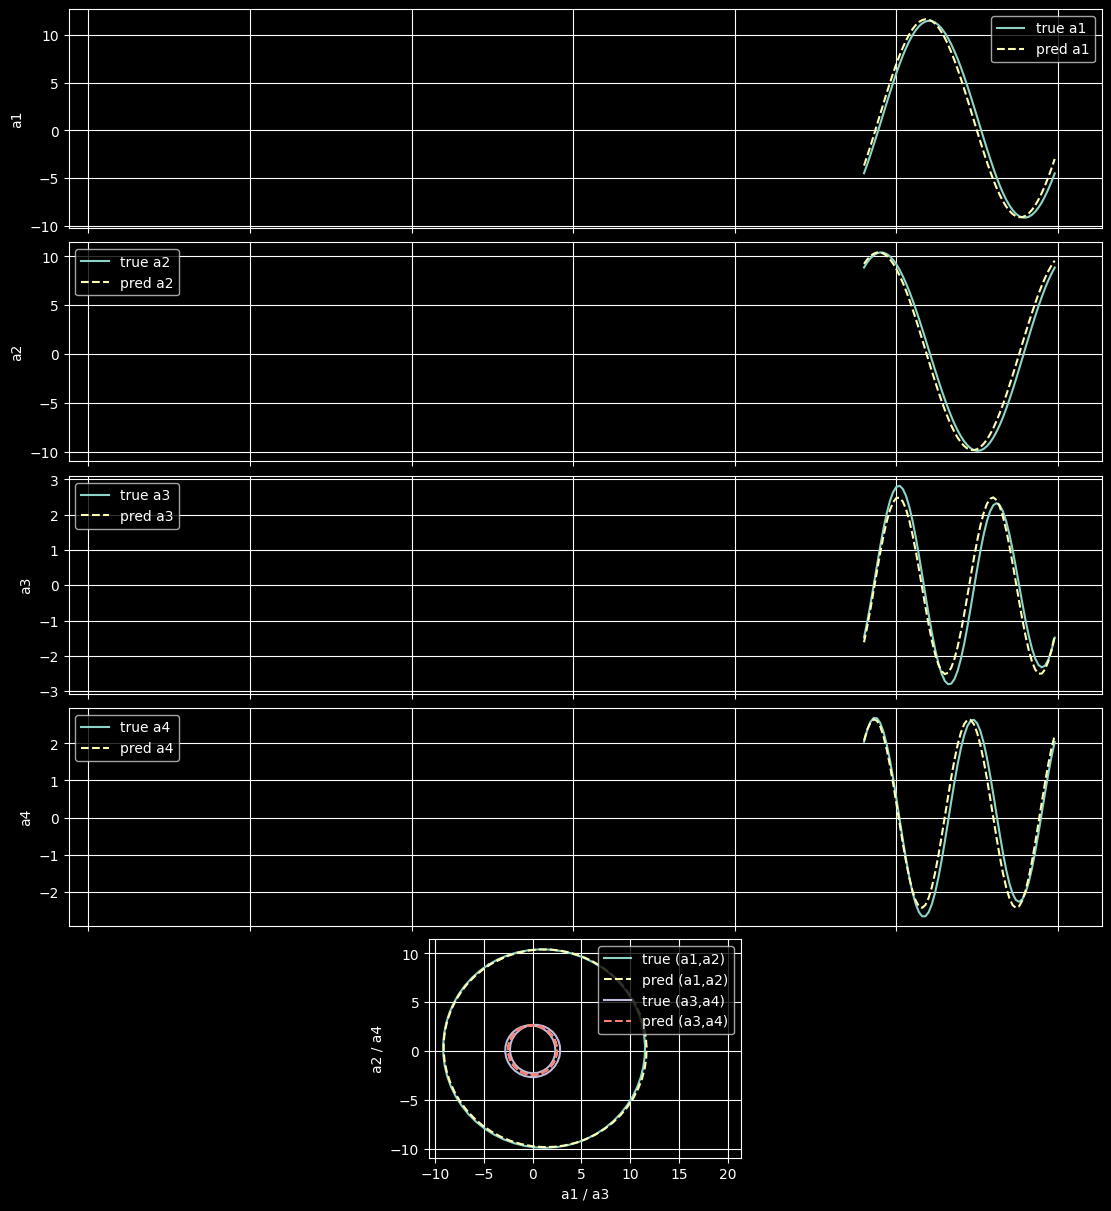

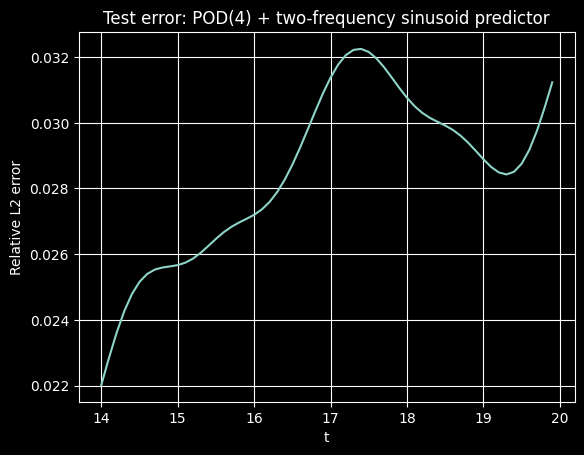

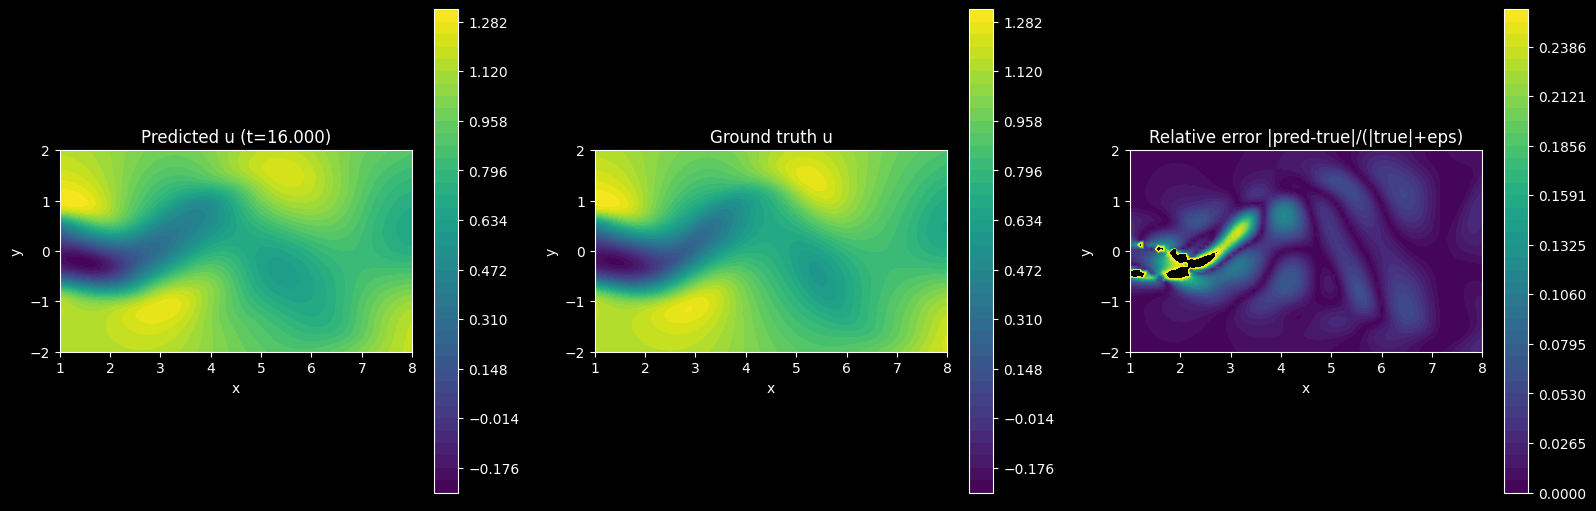

In [15]:

# -----------------------
# Plot coefficient comparisons
# -----------------------
a_true = Ate
a_pred = A_pred_test

fig, axs = plt.subplots(5, 1, figsize=(11, 12), sharex=True, constrained_layout=True)

labels = ["a1", "a2", "a3", "a4"]
for i in range(4):
    axs[i].plot(t_test, a_true[i, :], label=f"true {labels[i]}")
    axs[i].plot(t_test, a_pred[i, :], "--", label=f"pred {labels[i]}")
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)
    axs[i].legend()

# Phase portraits for both pairs
axs[4].plot(a_true[0, :], a_true[1, :], label="true (a1,a2)")
axs[4].plot(a_pred[0, :], a_pred[1, :], "--", label="pred (a1,a2)")
axs[4].plot(a_true[2, :], a_true[3, :], label="true (a3,a4)")
axs[4].plot(a_pred[2, :], a_pred[3, :], "--", label="pred (a3,a4)")
axs[4].set_xlabel("a1 / a3")
axs[4].set_ylabel("a2 / a4")
axs[4].set_aspect("equal", adjustable="box")
axs[4].grid(True)
axs[4].legend()

plt.show()

# -----------------------
# Reconstruct field on TEST and plot error
# -----------------------
X_pred_test = mean_field + (phi_r @ A_pred_test)  # (N, nt_test)
X_true_test = Xte  # (N, nt_test)

err = np.linalg.norm(X_true_test - X_pred_test, axis=0) / np.linalg.norm(X_true_test, axis=0)

plt.figure()
plt.plot(t_test, err)
plt.xlabel("t")
plt.ylabel("Relative L2 error")
plt.title("Test error: POD(4) + two-frequency sinusoid predictor")
plt.grid(True)
plt.show()

# -----------------------
# 3-panel field viz: pred, truth, relative error
# -----------------------
import matplotlib.tri as mtri

k_plot = min(20, len(test_idx) - 1)

xg = X_star[:, 0].reshape(-1)
yg = X_star[:, 1].reshape(-1)

u_pred = X_pred_test[:, k_plot].reshape(-1)
u_true = X_true_test[:, k_plot].reshape(-1)

eps = 1e-12
rel_err = np.abs(u_pred - u_true) / (np.abs(u_true) + eps)

tri = mtri.Triangulation(xg, yg)

fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

vmin = min(u_true.min(), u_pred.min())
vmax = max(u_true.max(), u_pred.max())
levels = np.linspace(vmin, vmax, 40)

c0 = axs[0].tricontourf(tri, u_pred, levels=levels)
fig.colorbar(c0, ax=axs[0])
axs[0].set_title(f"Predicted u (t={t_test[k_plot]:.3f})")
axs[0].set_xlabel("x");
axs[0].set_ylabel("y")
axs[0].set_aspect("equal")

c1 = axs[1].tricontourf(tri, u_true, levels=levels)
fig.colorbar(c1, ax=axs[1])
axs[1].set_title("Ground truth u")
axs[1].set_xlabel("x");
axs[1].set_ylabel("y")
axs[1].set_aspect("equal")

err_levels = np.linspace(0, np.percentile(rel_err, 99), 40)
c2 = axs[2].tricontourf(tri, rel_err, levels=err_levels)
fig.colorbar(c2, ax=axs[2])
axs[2].set_title("Relative error |pred-true|/(|true|+eps)")
axs[2].set_xlabel("x");
axs[2].set_ylabel("y")
axs[2].set_aspect("equal")

plt.show()